In [15]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

In [2]:
dataset_path = r"C:\Users\asus\Desktop\accident and no accident dataset"

In [3]:
#Defining Class Paths
accident_path = os.path.join(dataset_path, r"C:\Users\asus\Desktop\accident and no accident dataset\accident and no accident dataset\Accident")
non_accident_path = os.path.join(dataset_path, r"C:\Users\asus\Desktop\accident and no accident dataset\accident and no accident dataset\Non Accident")

accident_images = os.listdir(accident_path)
non_accident_images = os.listdir(non_accident_path)

print("Number of Accident images:", len(accident_images))
print("Number of Non Accident images:", len(non_accident_images))

Number of Accident images: 47
Number of Non Accident images: 47


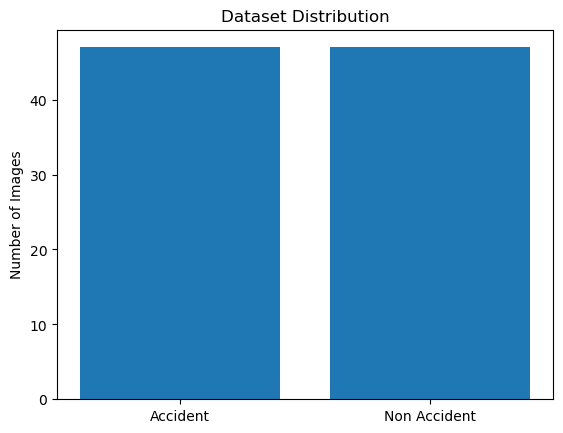

In [4]:
labels = ['Accident','Non Accident']
values = [len(accident_images),len(non_accident_images)]

plt.bar(labels,values)
plt.title("Dataset Distribution")
plt.ylabel("Number of Images")
plt.show()

In [5]:
#Creating Data Containers
data = []  #stores image pixel values
labels = [] #stores class labels

img_size = 128 #resized to 128 × 128

In [6]:
#Loading Accident Images
for img in accident_images:
    
    img_path = os.path.join(accident_path,img)
    
    img_read = cv2.imread(img_path)
    
    if img_read is not None:
        img_read = cv2.resize(img_read,(img_size,img_size))
        data.append(img_read)
        labels.append(1)

In [7]:
#Loading Non-Accident Images
for img in non_accident_images:
    
    img_path = os.path.join(non_accident_path,img)
    
    img_read = cv2.imread(img_path)
    
    if img_read is not None:
        img_read = cv2.resize(img_read,(img_size,img_size))
        data.append(img_read)
        labels.append(0)

In [8]:
#Converting to Arrays
X = np.array(data)
y = np.array(labels)

print("Dataset shape:",X.shape)

Dataset shape: (94, 128, 128, 3)


In [9]:
#Normalization
X = X / 255.0 #By dividing by 255 we normalize them to:0 – 1

In [10]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [13]:
#CNN Model Architecture
#Conv2D Extracts features like edges and shapes from images.
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2)) #Reduces feature map size

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1,activation='sigmoid'))

In [16]:
model.compile(
    optimizer='adam',  #Adaptive Moment Estimation(model learns efficiently)
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [17]:
#Model Training
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    validation_data=(X_test,y_test),
    batch_size=32
)

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 853ms/step - accuracy: 0.5333 - loss: 0.8324 - val_accuracy: 0.6316 - val_loss: 0.6811
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 422ms/step - accuracy: 0.5600 - loss: 0.7404 - val_accuracy: 0.3684 - val_loss: 0.7520
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 437ms/step - accuracy: 0.5467 - loss: 0.6933 - val_accuracy: 0.3684 - val_loss: 0.7122
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 402ms/step - accuracy: 0.5733 - loss: 0.6608 - val_accuracy: 0.3684 - val_loss: 0.7563
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 554ms/step - accuracy: 0.5333 - loss: 0.6863 - val_accuracy: 0.4211 - val_loss: 0.7097
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 536ms/step - accuracy: 0.6400 - loss: 0.6497 - val_accuracy: 0.3684 - val_loss: 0.7703
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 502ms/step - accuracy: 0.6000 - loss: 0.6619 - val_accuracy: 0.4211 - val_loss: 0.6966
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 512ms/step - accuracy: 0.7333 - loss: 0.6089 - val_accuracy: 0.4211 - val_loss:

In [18]:
model.save("accident_model01.keras")

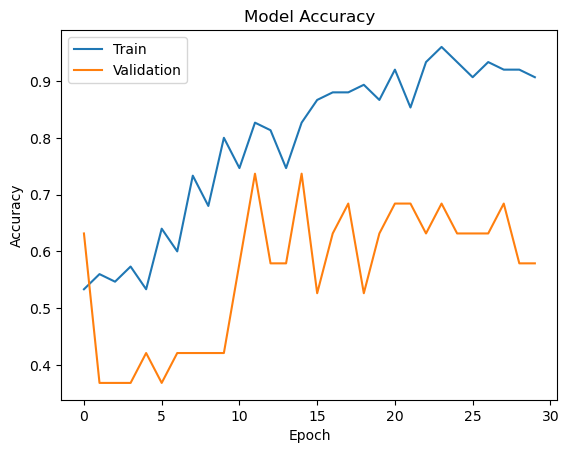

In [19]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Train','Validation'])
plt.show()

In [20]:
from tensorflow.keras.models import load_model

model = load_model("accident_model01.keras", compile=False)

img_path = r"C:\Users\asus\Desktop\accident and no accident dataset\accident and no accident dataset\Accident\test.jpg.jpg"

img = cv2.imread(img_path)
img = cv2.resize(img,(128,128))
img = img/255.0

img = np.expand_dims(img,axis=0)

prediction = model.predict(img)

print(prediction)

if prediction[0][0] > 0.5:
    print("Accident Detected")
else:
    print("No Accident")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step
[[0.40271252]]
No Accident
